<a href="https://colab.research.google.com/github/zakari90/machine-learning/blob/main/Regression_Predicting_sales_one_and__more_than_one_variable.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/hsoub ai/machine learning/regression/advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [ ]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [ ]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [ ]:
pd.DataFrame(df.isnull().sum(), columns =["Count of Null Values"]).T

,TV,Radio,Newspaper,Sales
Count of Null Values,0,0,0,0


In [ ]:
type(df[["TV"]])

pandas.core.frame.DataFrame

Many machine learning libraries (such as scikit-learn) expect the input features X to be 2D, so you should use:

In [ ]:
X = df[['TV']]
Y = df['Sales']
print(type(X))
print(type(Y))
print(X.shape)
print(Y.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
(200, 1)
(200,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8, random_state=50)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train.values, Y_train)

LinearRegression()

In [ ]:
b0 = round(model.intercept_,2)
b1 = round(model.coef_[0],2)

print('b0:', b0)
print('b1:', b1)

b0: 6.89
b1: 0.06


In [ ]:
Tv_advertisment = [[10]]

pred = model.predict(Tv_advertisment)
print("prediction= ", pred[0])

prediction=  7.4570537025615495


In [ ]:
Y_pred = model.predict(X_test.values)
Y_pred

array([16.85430492, 20.18899637,  8.23968537, 14.22851898, 12.34566599,
       19.27592609, 20.05288651,  7.37765629, 19.82036551, 11.89763771,
       20.48957229, 16.9280311 , 19.18518619, 16.67282512, 21.79962965,
       14.55745113, 13.75213448, 19.83737924,  9.32856421, 14.35895759,
       13.11695516, 11.160376  , 10.42311429, 19.50277585, 22.41212399,
       10.76906017, 12.01673384, 12.31730977, 17.37605937, 18.61806179,
       13.87123061, 15.38545274,  7.84836953, 18.09630735, 11.22275968,
        9.42497535, 12.71429684, 21.78828716, 11.83525403, 11.22275968])

In [ ]:
diffrence = Y_test - Y_pred
diffrence

,Sales
112,0.245695
165,-3.288996
12,0.960315
73,-3.228519
144,-0.045666
20,-1.275926
199,-1.652887
8,-2.577656
39,1.679634
88,1.002362


In [ ]:
deff = pd.DataFrame({'reel':Y_test, 'predicted':Y_pred, 'diffrence':diffrence})
deff

,reel,predicted,diffrence
112,17.1,16.854305,0.245695
165,16.9,20.188996,-3.288996
12,9.2,8.239685,0.960315
73,11.0,14.228519,-3.228519
144,12.3,12.345666,-0.045666
20,18.0,19.275926,-1.275926
199,18.4,20.052887,-1.652887
8,4.8,7.377656,-2.577656
39,21.5,19.820366,1.679634
88,12.9,11.897638,1.002362


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from numpy import sqrt

mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
rmse = sqrt(mse)

print('MSE:', mse)
print('MAE:', mae)
print('RMSE:', rmse)

MSE: 4.656501701168373
MAE: 1.7416080983197326
RMSE: 2.1578928845446366


<Axes: xlabel='Sales'>

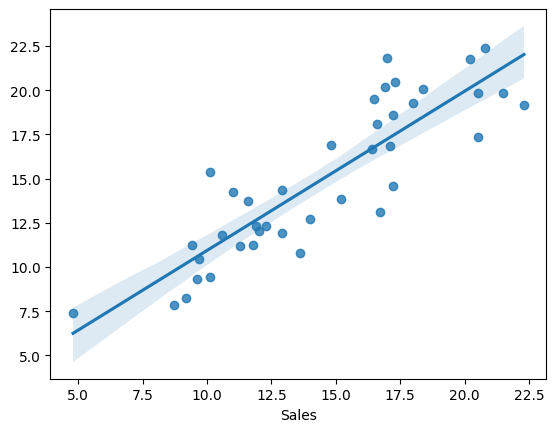

In [ ]:
from seaborn import regplot
regplot(x=Y_test, y= Y_pred)

multiples variables

In [ ]:
X2 = df[['TV', 'Radio', 'Newspaper']]
Y2 = df['Sales']

X_train2 , X_test2 , Y_train2 , Y_test2 = train_test_split(X2, Y2, train_size=0.8, random_state=50)

model2 = LinearRegression()
model2.fit(X_train2.values, Y_train2)

LinearRegression()

In [ ]:
model2.coef_

array([0.05505166, 0.10289854, 0.00435186])

In [ ]:
model2.intercept_

np.float64(4.51112802009103)

In [ ]:
print("Y = ", model2.intercept_, " + ", model2.coef_[0], "TV + ", model2.coef_[1], "Radio + ", model2.coef_[2], "newspaper")

Y =  4.51112802009103  +  0.05505165665994351 TV +  0.10289854060587736 Radio +  0.004351859068520592 newspaper


In [ ]:
advertisment = [[100, 50, 60]]

pred = model2.predict(advertisment)
print("prediction= ", pred[0])

In [ ]:
y_pred2 = model2.predict(X_test2.values)
y_pred2

array([15.77878608, 18.13963419,  9.71988374, 12.35754726, 11.49928311,
       19.61708868, 18.21140615,  5.20501106, 21.08144021, 12.31552854,
       18.2949829 , 15.24007957, 21.08194368, 16.00360445, 19.4292147 ,
       16.44473148, 12.24866175, 18.93242528,  9.63263457, 13.80533867,
       15.69803572, 10.88679356,  9.31700686, 17.16148085, 22.81234026,
       13.01057258,  9.61963047,  9.95583328, 16.94678959, 16.51530909,
       14.90223951, 12.99738447, 10.32722344, 17.84866777,  8.86380094,
        9.71636772, 13.24728558, 22.00587075, 10.63854841, 11.56151208])

<Axes: xlabel='Sales'>

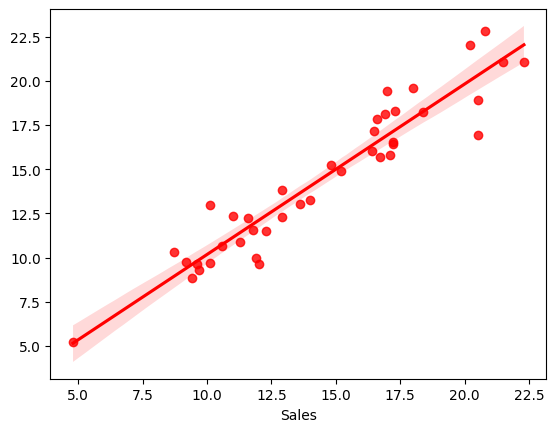

In [ ]:
regplot(x= Y_test2, y = y_pred2, color="red" )

In [ ]:
mae2 = mean_absolute_error(Y_test2, y_pred2)
mse2 = mean_squared_error(Y_test2, y_pred2)
rmse2 = sqrt(mse2)

print('MSE 2:', mse2)
print('MAE 2:', mae2)
print('RMSE 2:', rmse2)

MSE 2: 1.7017494480435964
MAE 2: 1.0322816775439967
RMSE 2: 1.3045111912297251


nonlinear regression

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features (e.g., degree 2 for squares and interaction terms)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X2_poly = poly_features.fit_transform(X2)

# Split the polynomial features into training and testing sets
X_train_poly, X_test_poly, Y_train_poly, Y_test_poly = train_test_split(X2_poly, Y2, train_size=0.8, random_state=50)

# Train a Linear Regression model on the polynomial features
model_poly = LinearRegression()
model_poly.fit(X_train_poly, Y_train_poly)

LinearRegression()

<Axes: xlabel='Sales'>

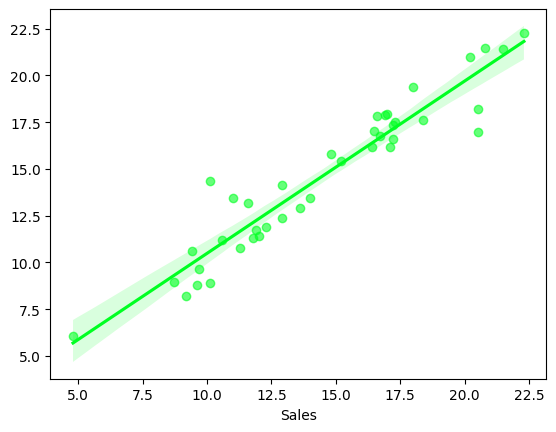

In [ ]:
y_pred_poly = model_poly.predict(X_test_poly)
regplot(x=Y_test_poly, y=y_pred_poly, color="#00ff22", scatter_kws={'alpha':0.6})
